In [4]:
#从原来检测dfg和ape是否在之后继续运行
import glob as glob
import subprocess
from Bio.PDB import PDBParser,PDBIO, PPBuilder
import warnings
from Bio import BiopythonParserWarning
from Bio.PDB.PDBExceptions import PDBConstructionWarning
import pandas as pd
import numpy as np
import pickle as p 
# 忽略 PDB 构建过程中的警告
warnings.simplefilter('ignore', PDBConstructionWarning)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from tqdm.notebook import tqdm
import os
from pprint import pprint as pp
from tools import clean_folder

three_to_one = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D',
    'CYS': 'C', 'GLU': 'E', 'GLN': 'Q', 'GLY': 'G',
    'HIS': 'H', 'ILE': 'I', 'LEU': 'L', 'LYS': 'K',
    'MET': 'M', 'PHE': 'F', 'PRO': 'P', 'SER': 'S',
    'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

copy pdbs file to a new folder

In [5]:
def create_nonreconstructed_folder():
    unaligned_dir = "Results/activation_segments/unaligned"
    reconstructed_dir = "Results/activation_segments/reconstructedModeller"
    target_dir = "Results/activation_segments/nonReconstructed4Mustang"
    
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created directory: {target_dir}")
    
    unaligned_files = [f for f in os.listdir(unaligned_dir) if f.endswith('.pdb')]
    reconstructed_files = [f for f in os.listdir(reconstructed_dir) if f.endswith('.pdb')]
    
    # Extract the first 6 characters of each reconstructed filename to identify corresponding entries
    reconstructed_prefixes = {f[:6] for f in reconstructed_files}
    
    copied_count = 0
    skipped_count = 0
    
    for unaligned_file in unaligned_files:
        file_prefix = unaligned_file[:6]
        
        if file_prefix in reconstructed_prefixes:
            source_path = os.path.join(unaligned_dir, unaligned_file)
            target_path = os.path.join(target_dir, unaligned_file)
            
            # Copy unaligned file to the target directory if it was reconstructed
            shutil.copy(source_path, target_path)
            copied_count += 1
        else:
            skipped_count += 1
    
    print(f"Copied {copied_count} files from '{unaligned_dir}' to '{target_dir}'")
    print(f"Skipped {skipped_count} files that don't have matching entries in '{reconstructed_dir}'")
    print(f"These files have matching entries in '{reconstructed_dir}' based on the first 6 characters")

if __name__ == '__main__':
    create_nonreconstructed_folder()
    print("Processing complete!")

Copied 3847 files from 'Results/activation_segments/unaligned' to 'Results/activation_segments/nonReconstructed4Mustang'
Skipped 8468 files that don't have matching entries in 'Results/activation_segments/reconstructedModeller'
These files have matching entries in 'Results/activation_segments/reconstructedModeller' based on the first 6 characters
Processing complete!


Select the structures whose have DFG and APE

In [6]:
"""
Filter PDB files from a directory that contain the specific structural motifs DFG and APE, ensuring that they appear in a valid order (with DFG preceding APE and a reasonable distance between them). Qualified structures are copied to a new directory for further use, and all processing details are recorded in a log file for review and traceability.
"""
import os
import shutil
from glob import glob
from Bio.PDB import PDBParser, PPBuilder

pdb_dir = "Results/activation_segments/nonReconstructed4Mustang/"
filtered_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered/"
log_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered/"
log_file = os.path.join(log_dir, "motif_verification_log.txt")

os.makedirs(filtered_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

print(f"Created/verified directories:\n- {filtered_dir}\n- {log_dir}")

with open(log_file, 'w') as f:
    f.write("Motif Verification Log\n")
    f.write("=====================\n\n")

def log_message(message):
    """Write message to log file and print to console."""
    print(message)
    try:
        with open(log_file, 'a') as f:
            f.write(message + "\n")
    except Exception as e:
        print(f"WARNING: Could not write to log file: {e}")

def extract_atom_sequence(pdb_file):
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure('PDB', pdb_file)
        
        for model in structure:
            for chain in model:
                ppb = PPBuilder()
                sequence = ''
                for pp in ppb.build_peptides(chain):
                    sequence += pp.get_sequence()
                return str(sequence)
    except Exception as e:
        log_message(f"Error extracting sequence from {pdb_file}: {e}")
    return None

def find_motif_indices(seq, motif):
    index = seq.find(motif)
    if index == -1:
        return None
    return index, index + len(motif)

def find_dfg_motif_index(seq):
    for motif in ["DFG"]:
        result = find_motif_indices(seq, motif)
        if result is not None:
            return result, motif
    return None, None

def find_ape_motif_index(seq):
    for motif in ["APE"]:
        result = find_motif_indices(seq, motif)
        if result is not None:
            return result, motif
    return None, None

def filter_structures_by_motifs():
    # Check if input directory exists
    if not os.path.exists(pdb_dir):
        log_message(f"ERROR: Input directory does not exist: {pdb_dir}")
        return False
        
    fps = glob(pdb_dir + "/*.pdb")
    log_message(f"Found {len(fps)} PDB files to check.")
    
    valid_count = 0
    invalid_count = 0
    
    for fp in fps:
        pdb_code = os.path.basename(fp).split('.')[0]
        log_message(f"\nChecking {pdb_code}...")
        
        seq = extract_atom_sequence(fp)
        if seq is None:
            log_message(f"  - Could not extract sequence. Skipping.")
            invalid_count += 1
            continue
        
        dfg_result, dfg_motif = find_dfg_motif_index(seq)
        
        ape_result, ape_motif = find_ape_motif_index(seq)

        # Only keep files where both DFG and APE motifs are found
        if dfg_result is not None and ape_result is not None:
            dfg_start, dfg_end = dfg_result
            ape_start, ape_end = ape_result
            
            # Motifs must appear in correct order and be at least 5 residues apart
            if dfg_start < ape_start and (ape_start - dfg_end) >= 5:
                log_message(f"  - Found {dfg_motif} at position {dfg_start} and {ape_motif} at position {ape_start}")
                
                # Copy the valid PDB file to the filtered directory
                dest_path = os.path.join(filtered_dir, os.path.basename(fp))
                shutil.copy(fp, dest_path)
                log_message(f"  - Copying to {dest_path}")
                valid_count += 1
            else:
                log_message(f"  - Found motifs but in wrong order or too close: {dfg_motif}({dfg_start}) and {ape_motif}({ape_start})")
                invalid_count += 1
        else:
            # Log which motif was missing
            if dfg_result is None:
                log_message(f"  - DFG motif not found")
            if ape_result is None:
                log_message(f"  - APE motif not found")
            invalid_count += 1
    
    # Summary of results
    log_message(f"\nFiltering complete:")
    log_message(f"  - {valid_count} structures have valid DFG and APE motifs")
    log_message(f"  - {invalid_count} structures were excluded")
    log_message(f"  - Valid structures copied to {filtered_dir}")
    
    return valid_count > 0

if __name__ == '__main__':
    log_message(f"Starting filtering process. Working directory: {os.getcwd()}")
    log_message(f"Using input directory: {pdb_dir}")
    log_message(f"Output directory: {filtered_dir}")
    
    log_message("Filtering structures based on presence of DFG and APE motifs...")
    motifs_present = filter_structures_by_motifs()
    
    if motifs_present:
        log_message("\nFiltering process complete! Filtered structures saved to:")
        log_message(filtered_dir)
    else:
        log_message("No valid structures found with both DFG and APE motifs.")

Created/verified directories:
- Results/activation_segments/nonReconstructed4Mustang_filtered/
- Results/activation_segments/nonReconstructed4Mustang_filtered/
Starting filtering process. Working directory: /data/student/xujia/auto_newnew
Using input directory: Results/activation_segments/nonReconstructed4Mustang/
Output directory: Results/activation_segments/nonReconstructed4Mustang_filtered/
Filtering structures based on presence of DFG and APE motifs...
Found 3847 PDB files to check.

Checking 4FZ6_A...
  - Found DFG at position 142 and APE at position 166
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/4FZ6_A.pdb

Checking 6VNL_B...
  - Found DFG at position 159 and APE at position 186
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/6VNL_B.pdb

Checking 8AHG_A...
  - Found DFG at position 159 and APE at position 183
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/8AHG_A.pdb

Checking 7E75_A...
  

Extract +-40 from pdb files and stores the new pdbs in a new folder

In [7]:
def crop_pdb_by_motifs(input_file, output_file):
    parser = PDBParser(PERMISSIVE=1)
    structure = parser.get_structure('protein', input_file)
    ppb = PPBuilder() # 用于从结构中提取序列

    # 1. 尝试从结构中提取序列并定位 DFG/APE
    target_res_ids = []
    found_motifs = False

    for model in structure:
        for chain in model:
            # 获取该链的序列
            sequence = ""
            residues = [r for r in chain if r.get_id()[0] == ' '] # 只保留标准氨基酸
            for r in residues:
                # 简单映射，你可以根据需要使用更复杂的映射表
                try:
                    sequence += three_to_one[r.get_resname()]
                except:
                    sequence += 'X'

            # 在序列中搜索
            dfg_pos = sequence.find("DFG")
            ape_pos = sequence.find("APE")

            if dfg_pos != -1 and ape_pos != -1:
                # 2. 映射回 PDB 编号
                dfg_res_num = residues[dfg_pos].get_id()[1]
                ape_res_num = residues[ape_pos].get_id()[1]
                
                # 定义保留区间 (DFG-40 到 APE+40)

                keep_range_1 = range(dfg_res_num - 40, dfg_res_num + 3)
                keep_range_2 = range(ape_res_num, ape_res_num + 43)
                # 3. 删除不在范围内的残基
                all_ids = [r.get_id() for r in chain]
                for rid in all_ids:
                    keep1=rid[1] in keep_range_1
                    keep2=rid[1] in keep_range_2
                    if rid[0] != ' ' or not (keep1 or keep2):
                        chain.detach_child(rid)
                found_motifs = True
                break # 找到一个链有 DFG 即可
        if found_motifs: break

    # 4. 保存结果
    if found_motifs:
        io = PDBIO()
        io.set_structure(structure)
        io.save(output_file)
        return True
    else:
        print(f"Warning: DFG or APE not found in {input_file}")
        return False
    

input_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered"
output_dir = "Results/nonReconstructed4Mustang_filtered_40"
os.makedirs(output_dir, exist_ok=True)
clean_folder(output_dir)


for pdb_name in os.listdir(input_dir):
    if pdb_name.endswith(".pdb"):
        try:
            crop_pdb_by_motifs(os.path.join(input_dir, pdb_name), 
                               os.path.join(output_dir, pdb_name))
            print(f"Processed {pdb_name} successfully.")
        except Exception as e:
            print(f"Error processing {pdb_name}: {e}")

Processed 4FZ6_A.pdb successfully.
Processed 6VNL_B.pdb successfully.
Processed 8AHG_A.pdb successfully.
Processed 7E75_A.pdb successfully.
Processed 3AGL_A.pdb successfully.
Processed 8V2F_C.pdb successfully.
Processed 5DA3_A.pdb successfully.
Processed 5N3R_A.pdb successfully.
Processed 3D83_A.pdb successfully.
Processed 5LCT_A.pdb successfully.
Processed 4NU1_A.pdb successfully.
Processed 3TKI_A.pdb successfully.
Processed 3E92_A.pdb successfully.
Processed 4Z84_A.pdb successfully.
Processed 6DRW_A.pdb successfully.
Processed 4KS7_A.pdb successfully.
Processed 5FWM_K.pdb successfully.
Processed 3WF9_A.pdb successfully.
Processed 4QYG_A.pdb successfully.
Processed 4EK5_A.pdb successfully.
Processed 5AUZ_A.pdb successfully.
Processed 6CD6_A.pdb successfully.
Processed 2YM7_A.pdb successfully.
Processed 6NFY_A.pdb successfully.
Processed 3QRI_B.pdb successfully.
Processed 4E4L_E.pdb successfully.
Processed 4ZK5_B.pdb successfully.
Processed 5M0B_A.pdb successfully.
Processed 8AHH_A.pdb

extract +-40 residue of template 

In [8]:
template = "6UAN_chainD.pdb"
crop_pdb_by_motifs(template, f"{template[:-4]}_40.pdb")
print(f"{template} processed successfully.")

6UAN_chainD.pdb processed successfully.


use foldseek to do structure alignment

In [9]:
print("Work folder:", os.getcwd())
os.chdir(os.getcwd())
foldseek_path="/data/student/xujia/miniforge3/envs/project/bin/foldseek"

prepare_template_pdb=[foldseek_path, 'createdb', '6UAN_chainD_40.pdb', 'foldseekDB/queryDB']

prepare_target_pdb=[foldseek_path, 'createdb', 'Results/nonReconstructed4Mustang_filtered_40/','foldseekDB/targetDB']

#prepare_target_pdb=[foldseek_path, 'createdb', "/data/student/xujia/auto_newnew/Results/activation_segments/nonReconstructed4Mustang_filtered_40",'foldseekDB/targetDB']
os.makedirs("foldseekDB", exist_ok=True)

prepare_prefilterDB=[foldseek_path, 'prefilter', 'foldseekDB/queryDB','foldseekDB/targetDB','foldseekDB/prefilterDB',
                     "--max-seqs", "4000",
                     "-s", "9.5",
                     "--target-search-mode", "1"]
#foldseek_alignment=[foldseek_path, "align", "queryDB", "targetDB", "alnRes", "tmp", "-a", 
#    "--format-output", str("query,target,rmsd,translation,rotation")]

foldseek_alignment=[foldseek_path, "structurealign", "foldseekDB/queryDB", "foldseekDB/targetDB", "foldseekDB/prefilterDB", 
                    "foldseekDB/outputDB", "-a"]

convert_alignment=[foldseek_path, "convertalis", "foldseekDB/queryDB", "foldseekDB/targetDB","foldseekDB/outputDB", "Results.m8",
    "--format-output", str("query,target,fident,alnlen,rmsd,t,u,qaln,taln")]

subprocess.run(prepare_template_pdb)
subprocess.run(prepare_target_pdb)  
subprocess.run(prepare_prefilterDB)
subprocess.run(foldseek_alignment)
subprocess.run(convert_alignment)

Work folder: /data/student/xujia/auto_newnew
foldseekDB/queryDB exists and will be overwritten
createdb 6UAN_chainD_40.pdb foldseekDB/queryDB 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	32
Verbosity                   	3

Output file: foldseekDB/queryDB
[=================================================================] 1 0s 4ms
Time for merging to queryDB_ss: 0h 0m 0s 3ms
Time for merging to queryDB_h: 0h 0m 0s 4ms
Time for merging to queryDB_ca: 0h 0m 0s 3ms
Time for merging to queryDB: 0h 0m 0s 3ms
Ignore 0 out of 1.
Too short: 0, incorrect: 0, not proteins: 0.
Time for processing: 0h 0m 0s 

CompletedProcess(args=['/data/student/xujia/miniforge3/envs/project/bin/foldseek', 'convertalis', 'foldseekDB/queryDB', 'foldseekDB/targetDB', 'foldseekDB/outputDB', 'Results.m8', '--format-output', 'query,target,fident,alnlen,rmsd,t,u,qaln,taln'], returncode=0)

Apply result matrix to original pdb to get the sequence

In [10]:

from tools import clean_folder
m8_file="Results.m8"
input_pdb_dir="Results/activation_segments/nonReconstructed4Mustang_filtered"
output_dir = "Results/activation_segments/Mustang_with_singlechain_withoutlier"
os.makedirs(output_dir, exist_ok=True)
clean_folder(output_dir)
count=0

def apply_foldseek_alignment(m8_file, pdb_dir, output_dir):
    """
    读取m8文件并应用矩阵变换保存PDB
    :param m8_file: Foldseek生成的m8结果文件路径
    :param pdb_dir: 存放原始PDB文件的文件夹
    :param output_dir: 结果存放文件夹
    """
    global count
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    clean_folder(output_dir)  # 清空输出文件夹，确保只保存当前结果

    # 1. 读取 m8 文件
    # 根据你提供的格式：query, target, fident, alnlen, rmsd, t, u, qaln, taln
    cols = ['query', 'target', 'fident', 'alnlen', 'rmsd', 't', 'u', 'qaln', 'taln']
    df = pd.read_csv(m8_file, sep='\t', header=None, names=cols)

    parser = PDBParser(QUIET=True)
    io = PDBIO()

    for _, row in df.iterrows():
        target_name = row['target']
        # 兼容处理：如果 target 是 5VAM_A 这种格式，尝试匹配 5VAM_A.pdb 或 5VAM.pdb
        pdb_path = os.path.join(pdb_dir, f"{target_name}.pdb")
        
        if not os.path.exists(pdb_path):
            print(f"找不到 PDB 文件: {pdb_path}，跳过。")
            continue

        # 2. 解析矩阵和向量
        # t 向量格式: t1,t2,t3 -> [3, 1]
        t_vec = np.array([float(x) for x in row['t'].split(',')]).reshape(3, 1)
        # u 矩阵格式: u1,u2...u9 -> [3, 3]
        u_mat = np.array([float(x) for x in row['u'].split(',')]).reshape(3, 3)

        # 3. 加载 PDB 并应用变换
        structure = parser.get_structure(target_name, pdb_path)
        
        # 遍历所有原子坐标进行变换,包括ASER和BSEr的!!!!!!!
        for atom in structure.get_atoms():
            if atom.is_disordered():
                # 遍历该原子下的所有物理构象（例如 ASER 和 BSER）
                for alt_atom in atom.disordered_get_list():
                    v_old = alt_atom.get_coord().reshape(3, 1)
                    v_new = np.dot(u_mat, v_old) + t_vec
                    alt_atom.set_coord(v_new.flatten())
            else:
                # 正常没有选择性构象的原子
                v_old = atom.get_coord().reshape(3, 1)
                v_new = np.dot(u_mat, v_old) + t_vec
                atom.set_coord(v_new.flatten())

        # 4. 保存对齐后的 PDB
        output_path = os.path.join(output_dir, f"{target_name}.pdb")
        io.set_structure(structure)
        io.save(output_path)
        print(f"finish apply the matrix to pdb: {target_name}, save the results to {output_path}")
        count+=1
        
apply_foldseek_alignment(m8_file, input_pdb_dir, output_dir)

print(f"totally {count} pdb files have been processed and saved to {output_dir}.")

finish apply the matrix to pdb: 6UAN_C, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/6UAN_C.pdb
finish apply the matrix to pdb: 5VAM_A, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/5VAM_A.pdb
finish apply the matrix to pdb: 6U2H_D, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/6U2H_D.pdb
finish apply the matrix to pdb: 4EHE_B, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/4EHE_B.pdb
finish apply the matrix to pdb: 3TV4_B, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/3TV4_B.pdb
finish apply the matrix to pdb: 4PP7_B, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/4PP7_B.pdb
finish apply the matrix to pdb: 3SKC_B, save the results to Results/activation_segments/Mustang_with_singlechain_withoutlier/3SKC_B.pdb
finish apply the matrix to pdb: 4MBJ_B, save the

draw the RMSD graph correspond to the +-40 residue area 

In [11]:
#Store m8 file into pandas dataframe
cols=["query","target","fident","alnlen","rmsd","t","u","qaln","taln"]
df = pd.read_csv("Results.m8", sep='\t', header=None, names=cols)
print(f"{df.shape[0]} alignments have been found by foldseek.")

3205 alignments have been found by foldseek.


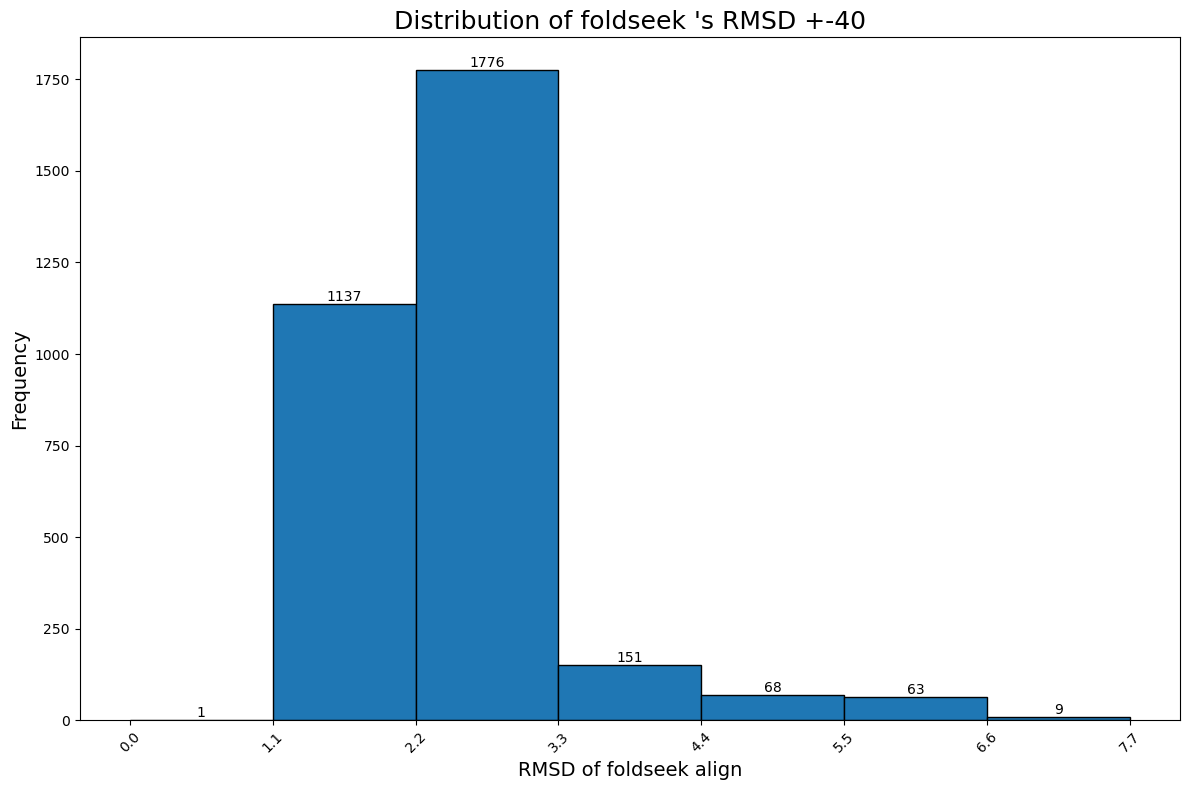

(0.0, 1.1]: 0 structures
(1.1, 2.2]: 1139 structures
  - 5VAM_A
  - 6U2H_D
  - 4EHE_B
  - 3TV4_B
  - 4PP7_B
  - 3SKC_B
  - 4MBJ_B
  - 6PP9_A
  - 4E4X_B
  - 6NYB_A
  - 4MNE_B
  - 6Q0J_A
  - 6Q0J_B
  - 6Q0K_A
  - 6Q0K_B
  - 6Q0T_A
  - 6Q0T_B
  - 8C7Y_A
  - 7M0T_A
  - 7M0Z_A
  - 5HID_B
  - 6V2W_A
  - 7M0Y_A
  - 7M0V_A
  - 8DGS_A
  - 3TV6_B
  - 6XFP_A
  - 7M0W_A
  - 7M0U_A
  - 7K0V_D
  - 7M0X_A
  - 8DGT_A
  - 8C7X_A
  - 6NSQ_A
  - 7K0V_B
  - 7MFD_A
  - 6P7G_B
  - 7MFE_A
  - 4H58_C
  - 6XLO_A
  - 4RZV_B
  - 4WO5_A
  - 3KXX_B
  - 3KXX_C
  - 3AC8_A
  - 1Y57_A
  - 5H2U_A
  - 4PUZ_A
  - 3KXX_D
  - 8PQH_A
  - 3VF8_A
  - 4I0S_A
  - 5D7V_A
  - 3D5W_A
  - 3DQW_D
  - 3VF9_A
  - 6ZCQ_A
  - 2HK5_A
  - 3CBL_A
  - 4FZ6_A
  - 1YI6_B
  - 4DFL_A
  - 4J52_A
  - 5CXZ_A
  - 5EG3_A
  - 6SSB_A
  - 1IR3_A
  - 2YAC_A
  - 3G0E_A
  - 4RWK_A
  - 4XG3_A
  - 6HM6_A
  - 1T46_A
  - 3BKB_A
  - 3RI1_A
  - 4DFN_A
  - 4FL1_A
  - 4XG3_B
  - 5GHV_A
  - 6VQM_B
  - 1YI6_A
  - 2OH4_A
  - 2PSQ_A
  - 3AC5_A
  - 3DQW_C
  - 4YJT_A
 

/tmp/ipykernel_3716433/4292917819.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rmsd["RMSD_bin"] = pd.cut(df_rmsd["rmsd"], bins=bins)
/tmp/ipykernel_3716433/4292917819.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_rmsd.groupby("RMSD_bin")["target"].apply(list)


In [12]:
df_rmsd=df[["query","target","rmsd"]]

plt.figure(figsize=(12, 8))

bin_width = 1.1
bins = np.arange(0, df_rmsd["rmsd"].max() + bin_width, bin_width)

n, bins_plot, patches = plt.hist(df_rmsd["rmsd"], bins=bins, edgecolor='black')

for count, x in zip(n, bins_plot[:-1]):
    if count > 0:
        plt.text(x + bin_width / 2, count, str(int(count)), ha='center', va='bottom', fontsize=10)
plt.xlabel("RMSD of foldseek align", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Distribution of foldseek 's RMSD +-40", fontsize=18)
plt.xticks(bins_plot, rotation=45, fontsize=10)
plt.tight_layout()

plt.show()

df_rmsd["RMSD_bin"] = pd.cut(df_rmsd["rmsd"], bins=bins)
grouped = df_rmsd.groupby("RMSD_bin")["target"].apply(list)

for interval, pdb_list in grouped.items():
    print(f"{interval}: {len(pdb_list)} structures")
    for pdb in pdb_list:
        print(f"  - {pdb}")

#plt.plot(df_rmsd["rmsd"])
#sns.histplot(df_rmsd["rmsd"], bins=30, kde=True)

output_txt = "rmsd_bins_with_pdb_names.txt"
with open(output_txt, "w") as f:
    for interval, pdb_list in grouped.items():
        f.write(f"{interval}: {len(pdb_list)} structures\n")
        for pdb in pdb_list:
            f.write(f"  - {pdb}\n")
        f.write("\n")  

Draw conservation curve,

Totally 3205 PDBs files are detected...
Finished 200/3205 PDBs file analysis
Finished 400/3205 PDBs file analysis
Finished 600/3205 PDBs file analysis
Finished 800/3205 PDBs file analysis
Finished 1000/3205 PDBs file analysis
Finished 1200/3205 PDBs file analysis
Finished 1400/3205 PDBs file analysis
Finished 1600/3205 PDBs file analysis
Finished 1800/3205 PDBs file analysis
Finished 2000/3205 PDBs file analysis
Finished 2200/3205 PDBs file analysis
Finished 2400/3205 PDBs file analysis
Finished 2600/3205 PDBs file analysis
Finished 2800/3205 PDBs file analysis
Finished 3000/3205 PDBs file analysis
Finished 3200/3205 PDBs file analysis


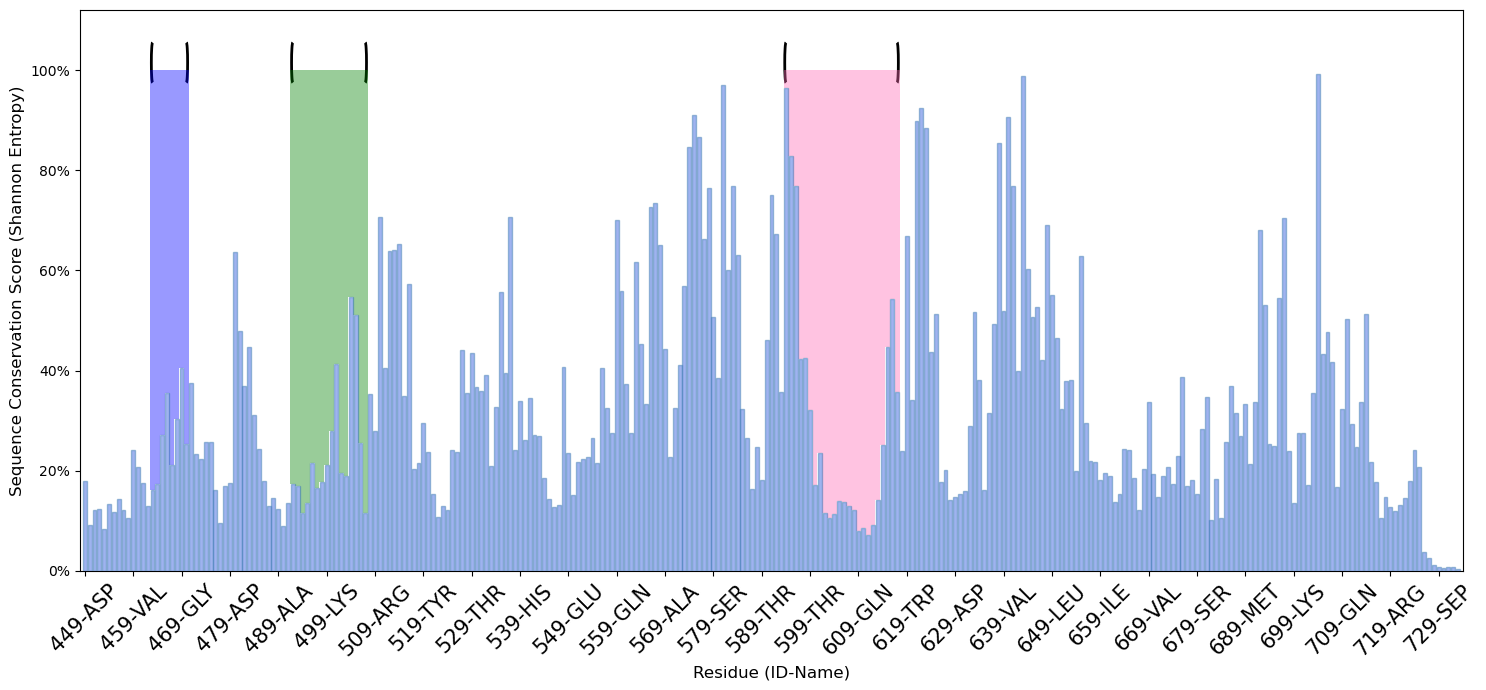

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Arc
from Bio.PDB import PDBParser, Polypeptide
import glob
import os
import collections

#如果CA为11以内，再继续判断是否为evolution，同一个点位的混乱程度，类似gini index

# 距离阈值
Radius_threshold = 11.0

# 使用你提供的转化字典
three_to_one = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D',
    'CYS': 'C', 'GLU': 'E', 'GLN': 'Q', 'GLY': 'G',
    'HIS': 'H', 'ILE': 'I', 'LEU': 'L', 'LYS': 'K',
    'MET': 'M', 'PHE': 'F', 'PRO': 'P', 'SER': 'S',
    'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

def calculate_shannon_entropy(amino_acids):
    """
    基于香农熵计算一列氨基酸的归一化保守率
    返回值在 [0, 1] 之间，1 表示完美保守，0 表示完全随机
    """
    # 过滤非标准残基或缺失值
    valid_aa = [aa for aa in amino_acids if aa in "ACDEFGHIKLMNPQRSTVWY"]
    if not valid_aa:
        return 0.0
    
    counts = collections.Counter(valid_aa)
    total = len(valid_aa)
    
    entropy = 0.0
    for aa, count in counts.items():
        p = count / total
        entropy -= p * np.log2(p)
        
    max_entropy = np.log2(20.0)
    conservation = 1.0 - (entropy / max_entropy) if max_entropy > 0 else 1.0
    
    # Gap 惩罚因子：如果很多 PDB 在这里没有残基（Gap），等比例扣减保守率得分
    gap_factor = len(valid_aa) / len(amino_acids)
    return conservation * gap_factor

def calculate_sequence_conservation_and_plot(template_pdb, pdb_folder, radius=Radius_threshold):
    parser = PDBParser(QUIET=True)
    run_count = 0
    
    # 1. 提取模板信息：坐标、残基名、原始编号
    ref_struct = parser.get_structure('ref', template_pdb)
    ref_atoms = []
    formatted_labels = [] 

    for res in ref_struct.get_residues():
        if 'CA' in res and Polypeptide.is_aa(res):
            ref_atoms.append(res['CA'])
            res_no = res.id[1]
            res_name = res.resname.upper()
            formatted_labels.append(f"{res_no}-{res_name}")

    ref_coords = np.array([atom.coord for atom in ref_atoms])
    num_residues = len(ref_coords)
    
    # 创建一个二维列表用于存放每个位置上所有 PDB 贡献的氨基酸单字母
    alignment_columns = [[] for _ in range(num_residues)]
    
    # 2. 遍历所有对齐后的 PDB，通过空间最邻近检索对应残基
    pdb_files = glob.glob(os.path.join(pdb_folder, "*.pdb"))
    total_pdbs = len(pdb_files)
    print(f"Totally {total_pdbs} PDBs files are detected...")

    for pdb_path in pdb_files:
        try:
            target_struct = parser.get_structure('target', pdb_path)
            # 获取目标蛋白中所有包含 CA 的氨基酸残基
            target_residues = [res for res in target_struct.get_residues() if 'CA' in res and Polypeptide.is_aa(res)]
            if not target_residues:
                for i in range(num_residues):
                    alignment_columns[i].append('-')
                continue
                
            target_coords = np.array([res['CA'].coord for res in target_residues])
            
            # 建立空间映射
            for i in range(num_residues):
                dists_sq = np.sum((target_coords - ref_coords[i])**2, axis=1)
                min_idx = np.argmin(dists_sq)
                
                if dists_sq[min_idx] < radius**2:
                    # 使用你提供的字典完成转换，找不到的记为 'X'
                    three_letter = target_residues[min_idx].resname.upper()
                    one_letter = three_to_one.get(three_letter, 'X')
                    alignment_columns[i].append(one_letter)
                else:
                    # 空间距离过远，视为发生了残基缺失或构象剧烈断裂，记为 Gap
                    alignment_columns[i].append('-')
                    
            run_count += 1
            if run_count % 200 == 0:
                print(f"Finished {run_count}/{total_pdbs} PDBs file analysis")
        except Exception:
            # 出现损坏文件时，这一档所有位点填空位，确保矩阵对齐
            for i in range(num_residues):
                alignment_columns[i].append('-')
            continue

    # 3. 计算每一列的香农熵保守率
    conservation = np.zeros(num_residues)
    for i in range(num_residues):
        conservation[i] = calculate_shannon_entropy(alignment_columns[i])

    # 4. 绘图部分（完全保留原有的可视化逻辑和样式）
    fig, ax = plt.subplots(1, figsize=(15, 7)) 
    x = np.arange(num_residues)

    # 绘制主柱状图
    ax.bar(x, conservation, color='royalblue', alpha=0.5, width=0.8, edgecolor='steelblue', zorder=10)

    # 设置自定义 X 轴标签
    step = 10
    ax.set_xticks(x[::step])
    ax.set_xticklabels([formatted_labels[i] for i in range(0, num_residues, step)], 
                       rotation=45, fontsize=15)

    # 标注功能区域 (pLoop, alphaC, Activation Loop)
    regions = [(14, 21, 'blue', 'pLoop'), (43, 58, 'green', 'alphaC'), (145, 168, 'hotpink', 'A-Loop')]
    
    for start, end, color, label in regions:
        # 弧线
        ax.add_patch(Arc((start, 1.015), 0.5, 0.08, theta1=90, theta2=270, color='black', lw=2))
        ax.add_patch(Arc((end, 1.015), 0.5, 0.08, theta1=-90, theta2=90, color='black', lw=2))
        
        # 阴影填充
        for i in range(start, end + 1):
            if i < num_residues:
                h = conservation[i]
                ax.add_patch(patches.Rectangle((i-0.5, h), 1, 1-h, facecolor=color, alpha=0.4, zorder=5))

    # 样式美化
    ax.set_ylim(0.0, 1.12)  # 下限调整为 0.0，完美契合香农熵的 [0, 1] 跨度
    ax.set_xlim(-1, num_residues)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.set_xlabel("Residue (ID-Name)", fontsize=12)
    ax.set_ylabel("Sequence Conservation Score (Shannon Entropy)", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# 运行
template_pdb = "6UAN_chainD.pdb"
pdb_folder = "Results/activation_segments/Mustang_with_singlechain_withoutlier"
calculate_sequence_conservation_and_plot(template_pdb, pdb_folder)

totally 3205 PDBs files are detected...
finished 200/3205 PDBs file analysis
finished 400/3205 PDBs file analysis
finished 600/3205 PDBs file analysis
finished 800/3205 PDBs file analysis
finished 1000/3205 PDBs file analysis
finished 1200/3205 PDBs file analysis
finished 1400/3205 PDBs file analysis
finished 1600/3205 PDBs file analysis
finished 1800/3205 PDBs file analysis
finished 2000/3205 PDBs file analysis
finished 2200/3205 PDBs file analysis
finished 2400/3205 PDBs file analysis
finished 2600/3205 PDBs file analysis
finished 2800/3205 PDBs file analysis
finished 3000/3205 PDBs file analysis
finished 3200/3205 PDBs file analysis


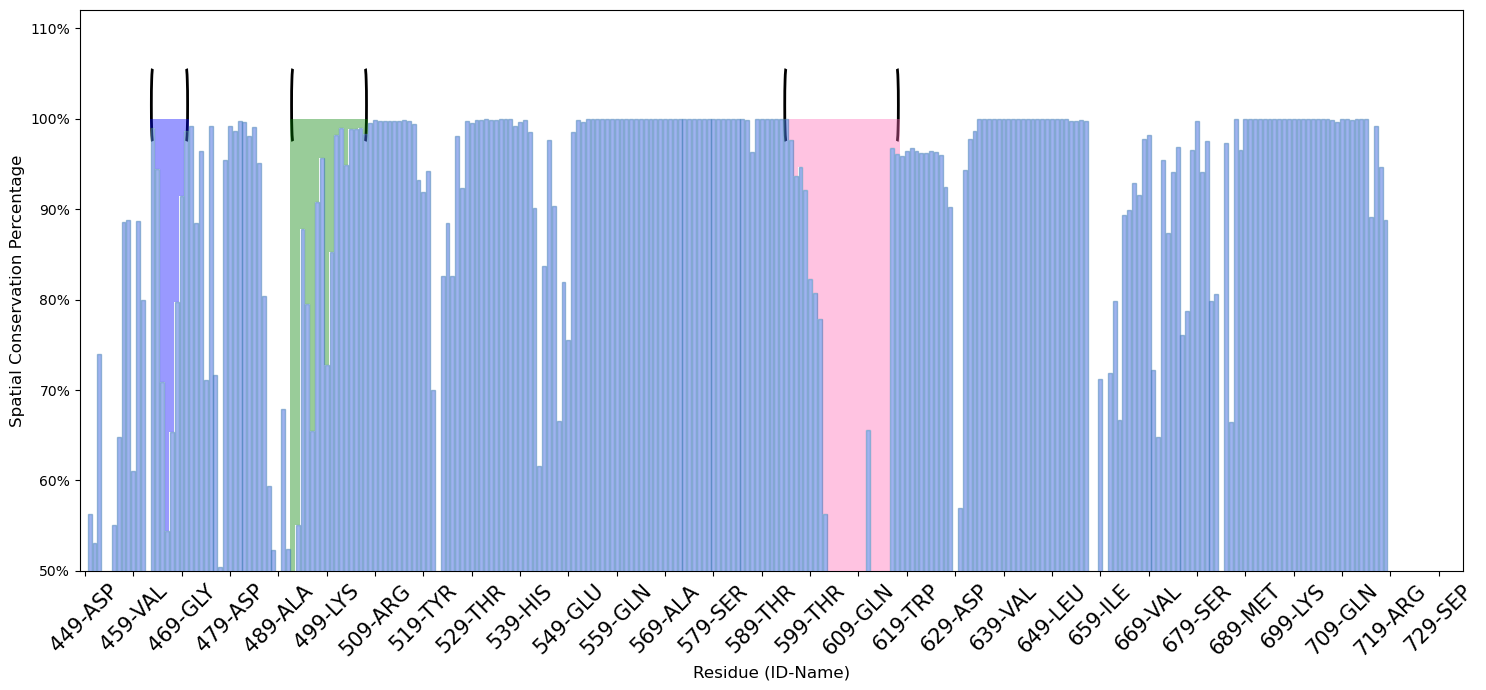

In [14]:
#计算的是位置，如果CA距离接近则为1，反之为0

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Arc
from Bio.PDB import PDBParser
import glob
import os

#
Radius_threshold=4.0


def calculate_conservation_and_plot(template_pdb, pdb_folder, radius=Radius_threshold):
    parser = PDBParser(QUIET=True)
    run_count=0
    # 1. 提取模板信息：坐标、残基名、原始编号
    ref_struct = parser.get_structure('ref', template_pdb)
    ref_atoms = []
    formatted_labels = [] # 用于存储 X 轴标签，如 "449-ASP"

    for res in ref_struct.get_residues():
        if 'CA' in res:
            ref_atoms.append(res['CA'])
            # 获取编号和残基名并格式化
            res_no = res.id[1]
            res_name = res.resname
            formatted_labels.append(f"{res_no}-{res_name}")

    ref_coords = np.array([atom.coord for atom in ref_atoms])
    num_residues = len(ref_coords)
    counts = np.zeros(num_residues)
    
    # 2. 空间坐标计算逻辑 (保持不变)
    pdb_files = glob.glob(os.path.join(pdb_folder, "*.pdb"))
    total_pdbs = len(pdb_files)
    print(f"totally {total_pdbs} PDBs files are detected...")

    for pdb_path in pdb_files:
        try:
            target_struct = parser.get_structure('target', pdb_path)
            target_coords = np.array([res['CA'].coord for res in target_struct.get_residues() if 'CA' in res])
            
            # 距离判断
            for i in range(num_residues):
                dists_sq = np.sum((target_coords - ref_coords[i])**2, axis=1)
                if np.min(dists_sq) < radius**2:
                    counts[i] += 1
            run_count+=1
            if run_count % 200 == 0:
                print(f"finished {run_count}/{total_pdbs} PDBs file analysis")
        except Exception:
            continue

    conservation = counts / total_pdbs

    # 3. 绘图部分
    fig, ax = plt.subplots(1, figsize=(15, 7)) # 增加宽度以适应较长的标签
    x = np.arange(num_residues)

    # 绘制主柱状图
    ax.bar(x, conservation, color='royalblue', alpha=0.5, width=0.8, edgecolor='steelblue', zorder=10)

    # --- 关键修改：设置自定义 X 轴标签 ---
    # 每隔 5 个或 10 个显示一个标签，避免太拥挤
    step = 10
    ax.set_xticks(x[::step])
    ax.set_xticklabels([formatted_labels[i] for i in range(0, num_residues, step)], 
                       rotation=45, fontsize=15)

    # 4. 标注功能区域 (pLoop, alphaC, Activation Loop)
    # 这里的 start/end 需要对应你在模板中的 index (从 0 开始计数)
    regions = [(14, 21, 'blue', 'pLoop'), (43, 58, 'green', 'alphaC'), (145, 168, 'hotpink', 'A-Loop')]
    
    for start, end, color, label in regions:
        # 弧线
        ax.add_patch(Arc((start, 1.015), 0.5, 0.08, theta1=90, theta2=270, color='black', lw=2))
        ax.add_patch(Arc((end, 1.015), 0.5, 0.08, theta1=-90, theta2=90, color='black', lw=2))
        
        # 阴影填充
        for i in range(start, end + 1):
            if i < num_residues:
                h = conservation[i]
                ax.add_patch(patches.Rectangle((i-0.5, h), 1, 1-h, facecolor=color, alpha=0.4, zorder=5))

    # 样式美化
    ax.set_ylim(0.5, 1.12)
    ax.set_xlim(-1, num_residues)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.set_xlabel("Residue (ID-Name)", fontsize=12)
    ax.set_ylabel("Spatial Conservation Percentage", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# 运行
template_pdb = "6UAN_chainD.pdb"
pdb_folder = "Results/activation_segments/Mustang_with_singlechain_withoutlier"
calculate_conservation_and_plot(template_pdb, pdb_folder)

In [15]:
"""Delete this outlier filter
"""
#将RMSD过大的删除或不正常的剔除，存到新的 dest_large里面


import os
import shutil
import re
# Input RMSD-bin file and RMSD cutoff threshold
txt_file = "rmsd_bins_with_pdb_names.txt"
rmsd_cutoff_large = 7.0

# Define source and destination directories for PDBs
source_dir="Results/activation_segments/Mustang_with_singlechain_withoutlier"
dest_large="Results/activation_segments/Mustang_with_singlechain"

pdbs_large = set()

# Read the text file and parse PDB names that fall within acceptable RMSD bins
with open(txt_file, "r") as f:
    current_rmsd_range = None
    for line in f:
        line = line.strip()
        if line.startswith("(") and "structures" in line:
            match = re.match(r"\(([\d.]+),\s*([\d.]+)]", line)
            if match:
                low = float(match.group(1))
                high = float(match.group(2))
                current_rmsd_range = (low, high)
        elif line.startswith("-"):
            pdb_id = line[1:].strip().split(".")[0]
            if current_rmsd_range and current_rmsd_range[1] <= rmsd_cutoff_large:
                pdbs_large.add(pdb_id)

os.makedirs(dest_large, exist_ok=True)

# Copy selected PDB files from source to destination folder
for pdb_id in pdbs_large:
    src = os.path.join(source_dir, f"{pdb_id}.pdb")
    dst = os.path.join(dest_large, f"{pdb_id}.pdb")
    if os.path.exists(src):
        shutil.copy2(src, dst)

count_large = len([f for f in os.listdir(dest_large) if f.endswith(".pdb")])
print(f"✅ Copied {count_large} PDBs to {dest_large}")

all_pdb_files = [f[:-4] for f in os.listdir(source_dir) if f.endswith(".pdb")]
not_in_large = sorted(set(all_pdb_files) - pdbs_large)
print(f"\nPDBs NOT in large set (RMSD > {rmsd_cutoff_large}): {len(not_in_large)} structures")
for name in not_in_large:
    print(f" - {name}")


✅ Copied 3282 PDBs to Results/activation_segments/Mustang_with_singlechain

PDBs NOT in large set (RMSD > 7.0): 10 structures
 - 2J51_A
 - 2JFL_A
 - 2JFM_A
 - 3FPM_A
 - 5CKW_A
 - 5CLR_A
 - 5CLR_B
 - 5E8X_A
 - 6T8X_B
 - 6UAN_C
